# Stochastic Differential Equation Safety Verification 
This notebook coordinates smooth gluing computation, Markov Chain Approximation construction, and PRISM verification.

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

from stochastic_verification import SDEConfig,PolynomialGluing, CInfinityGluing, BaseGluing, StochasticSimulator, generate_prism_ctmc_model, generate_prism_mdp_model, generate_pctl

%load_ext autoreload
%autoreload 2 

## 1. Setup

In [2]:


# with control
# tau = 0.5 
sigma =2.0
config = SDEConfig(
    mu = lambda x,u:u,
    sigma = lambda x:sigma,
    dt=0.02, 
    t_max=0.2, 
    h=0.005, 
    x_safe_min=-1.0,
    x_safe_max=1.0,
    epsilon=0.5,
    x_min=-2.5, 
    x_max=2.5,
    x_init=-0.5,
    U=[-3.0,3.0]
)

# without control
# tau = 0.5 
# sigma =1.5 
# config = SDEConfig(
#     mu = lambda x:-x/tau,
#     sigma = lambda x:sigma,
#     dt=0.01, 
#     t_max=0.5, 
#     h=0.001, 
#     x_safe_min=-1.0,
#     x_safe_max=1.0,
#     epsilon=0.3,
#     x_min=-1.5, 
#     x_max=1.5,
#     x_init=-0.5
# )



## 2. Polynomial Gluing and Error Computation

Weak Discretization Error Bound: 0.04980260993480683
Smoothing Error Bound: 0.13964369793544046
Total Error : 0.1894463078702473


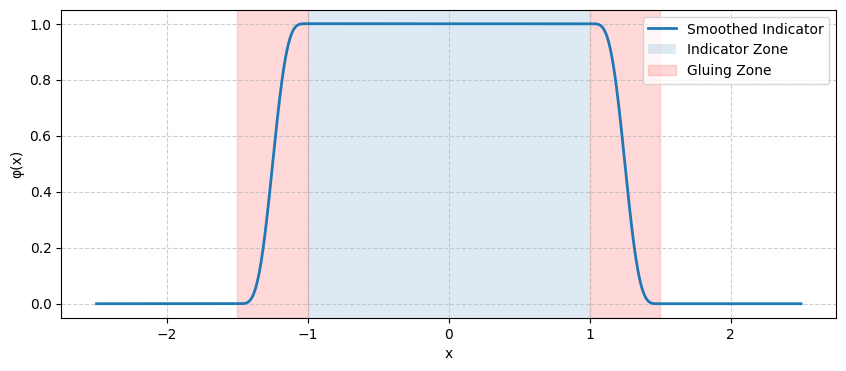

In [3]:
gluing = PolynomialGluing(config, degree=9)
gluing.plot()

(weak_error_bound,smoothing_error) = gluing.compute_error_bounds()
print(f"Weak Discretization Error Bound: {weak_error_bound}")
print(f"Smoothing Error Bound: {smoothing_error}")
total_error_poly = weak_error_bound+smoothing_error
print(f"Total Error : {total_error_poly}")

## Flat Gluing and Error Computation

Weak Discretization Error Bound: 0.18243033780322238
Smoothing Error Bound: 0.13964369744774047
Total Error : 0.32207403525096284


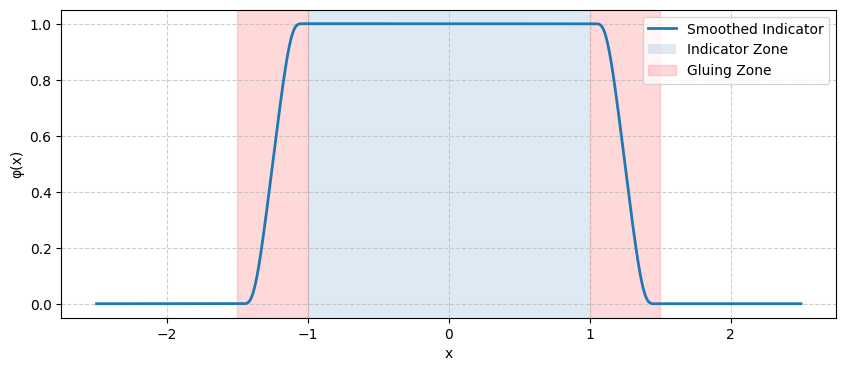

In [4]:
gluing = CInfinityGluing(config)
gluing.plot()

(weak_error_bound,smoothing_error) = gluing.compute_error_bounds()
print(f"Weak Discretization Error Bound: {weak_error_bound}")
print(f"Smoothing Error Bound: {smoothing_error}")
total_error_flat = weak_error_bound+smoothing_error
print(f"Total Error : {total_error_flat}")

total_error = min(total_error_poly,total_error_flat)


## 3. SDE vs MCA Simulation with coupled noise

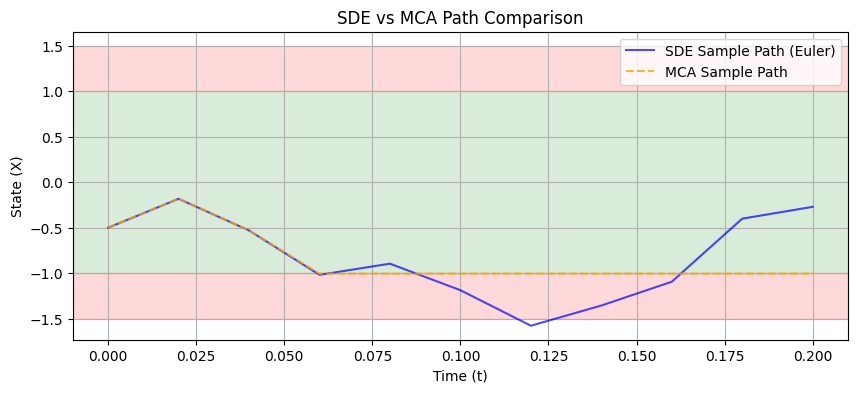

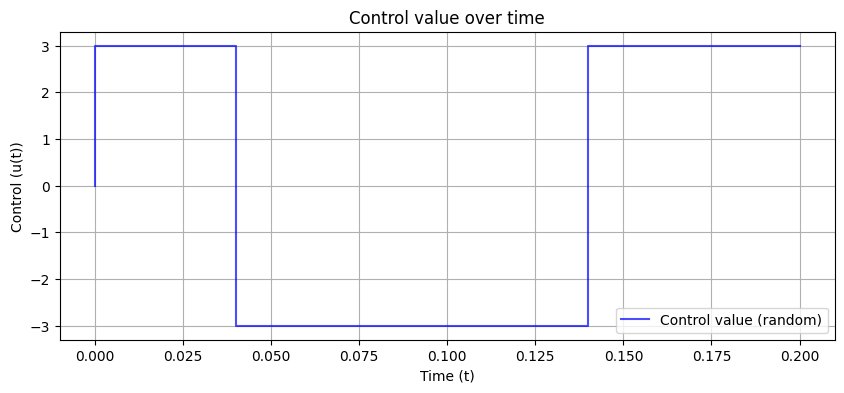

In [5]:
simulator = StochasticSimulator(config)
sim_results = simulator.run_monte_carlo(n_reps=20)
simulator.plot_one_sim(sim_results,n=1)
# Plot sample comparisons


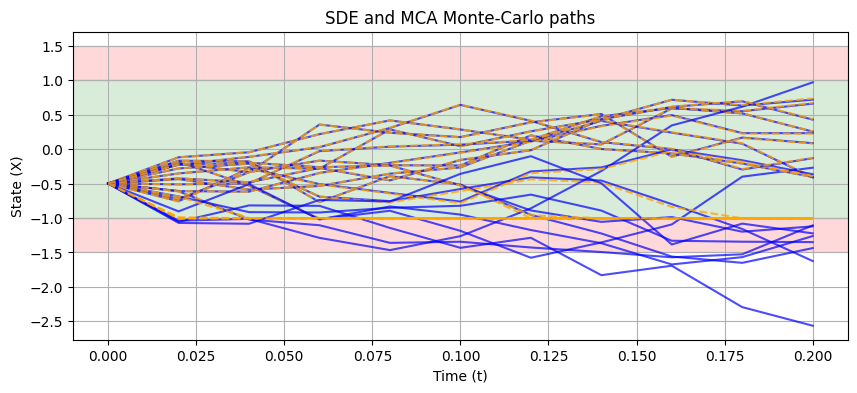

In [6]:
simulator.plot_mc_sims(sim_results)

## 4. Export to PRISM Model Checker

In [7]:
# Write prism model and pctl properties
if config.is_controlled:
    prism_code = generate_prism_mdp_model(config,simulator)
else:
    prism_code = generate_prism_ctmc_model(config,simulator)
prism_pctl = generate_pctl(config)

with open("ou_model.sm", "w") as file:
    file.write(prism_code)

print("PRISM model definition file written to 'ou_model.sm'.")

with open("ou_model.pctl", "w") as file:
    file.write(prism_pctl)

print("PRISM model properties file written to 'ou_model.pctl'.")

PRISM model definition file written to 'ou_model.sm'.
PRISM model properties file written to 'ou_model.pctl'.


## 5. PRISM Execution

In [ ]:
# Execute verification engine command line stream
prism_path = os.environ.get("PRISM_BIN", "/home/adrien/Tools/prism/prism-4.10-linux64-x86/bin/prism")
bash_command = f"{prism_path} ou_model.sm ou_model.pctl -exportresults res.txt"

print(f"Executing: {bash_command}")
os.system(bash_command)

Executing: /home/adrien/Tools/prism/prism-4.10-linux64-x86/bin/prism ou_model.sm ou_model.pctl -exportresults res.txt
PRISM
=====

Version: 4.10
Date: Thu Jun 11 14:53:32 CEST 2026
Hostname: latitude
Memory limits: cudd=1g, java(heap)=7.7g
Command line: prism ou_model.sm ou_model.pctl -exportresults res.txt

Parsing PRISM model file "ou_model.sm"...

Type:        MDP
Modules:     MCA_SDE
Actions:     [u0] [u1]
Variables:   s
Labels:      "safe"

Parsing properties file "ou_model.pctl"...

1 property:
(1) Pmax=? [ G<=T_max "safe" ]

---------------------------------------------------------------------

Model checking: Pmax=? [ G<=T_max "safe" ]
Property constants: T_max=10

Building model (engine:symbolic)...


## 6. SDE Verification Output

In [ ]:
if os.path.exists("res.txt"):
    with open("res.txt", "r") as file:
        prism_output = file.read()
    
    results = [float(val) for val in re.findall(r"Result:?\s*([0-9.eE+-]+)", prism_output)]
    
    if (not config.is_controlled) and len(results) == 2:
        safe_prob, terminal_safe_prob = results[:2]
        print(f"PRISM : Path Continuous Safety Probability (G <= T): {safe_prob:.6f}")
        print(f"PRISM : Fixed Horizon Transient Target Probability: {terminal_safe_prob:.6f}")
        safe_l = max(min(safe_prob-total_error,1.0),0.0)
        safe_r = max(min(safe_prob+total_error,1.0),0.0)
        print(f"SDE : Path Continuous Safety Probability (G <= T) interval: [{safe_l:.6f},{safe_r:.6f}]")
        terminal_safe_l = max(min(terminal_safe_prob-total_error,1.0),0.0)
        terminal_safe_r = max(min(terminal_safe_prob+total_error,1.0),0.0)
        print(f"SDE : Fixed Horizon Transient Target Probability interval: [{terminal_safe_l:.6f},{terminal_safe_r:.6f}]")
        
    elif config.is_controlled and len(results) == 1:
        safe_prob = results[0]
        print(f"PRISM : Max safety probability (G <= T): {safe_prob:.6f}")
        safe_l = max(min(safe_prob-total_error,1.0),0.0)
        safe_r = max(min(safe_prob+total_error,1.0),0.0)
        print(f"SDE : Max Safety Probability (G <= T) interval: [{safe_l:.6f},{safe_r:.6f}]")

    else : 
        print("PRISM file parsing completed but unexpected metrics length encountered.")
else:
    print("Results file 'res.txt' not found. Ensure PRISM path location configurations match operational environment specifications.")

ValueError: could not convert string to float: 'E'